In [84]:
import os
from IPython.display import Image, display
import operator
from pydantic.v1.fields import FieldInfo as FieldInfoV1
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import START, END, StateGraph
from langgraph.types import Command, interrupt
os.environ["HTTPS_PROXY"]="" #on some systems proxy is enabled. disabling will allow any network calls.

In [85]:
class State(TypedDict):
    nlist: Annotated[List[str],operator.add] # 

In [86]:
def nodeA(state: State) -> Command[Literal["b","c",END]]:
    print("Running node A")
    select = state["nlist"][-1]
    if select == "b":
        nextNode = "b"
    elif select == "c":
        nextNode =  "c"
    else:
        nextNode = END    
    return Command(
        update = State(nlist=[select]),goto = nextNode
    )

In [87]:
def nodeB(state: State) -> State:
    print("Running Node B")
    note = "Hello from Node B"
    return(State(nlist=[note]))

In [88]:
def nodeC(state: State) -> State:
    print("Running Node C")
    note = "Hello from Node C"
    return(State(nlist=[note]))

In [89]:
def condEdge(state: State) -> Command[Literal["b","c",END]]:
    select = state["nlist"][-1]
    if select == "b":
        return "b"
    elif select == "c":
        return "c"
    else:
        return END    

In [90]:
builder = StateGraph(State)
builder.add_node("a",nodeA)
builder.add_node("b",nodeB)
builder.add_node("c",nodeC)

builder.add_edge(START, "a")
builder.add_edge("b",END)
builder.add_edge("c",END)

#builder.add_conditional_edges("a",condEdge)
graph = builder.compile()


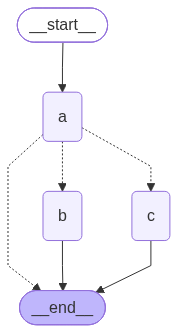

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	a(a)
	b(b)
	c(c)
	__end__([<p>__end__</p>]):::last
	__start__ --> a;
	a -.-> __end__;
	a -.-> b;
	a -.-> c;
	b --> __end__;
	c --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [91]:
display(Image(graph.get_graph().draw_mermaid_png()))
print(graph.get_graph().draw_mermaid())

In [92]:
userInput = input('b or c or anything else quit')
inputState = State(nlist=[userInput])
graph.invoke(inputState)

b or c or anything else quit c


Running node A
Running Node C


{'nlist': ['c', 'c', 'Hello from Node C']}